# DSP with a focus on audio signals
## Homework Assignment

**Author:** Onildo Duarte Sebastião Marraca
**Deadline:** March 20, 2026  
**Email:** onildoduartesebastiaom@gmail.com

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, linalg
from IPython.display import Audio, display

In [2]:
def play(x, sr):
    display(Audio(x, rate=sr))

def plot_time(x, sr, title='Time signal', seconds=0.05):
    n = min(len(x), int(seconds*sr))
    tt = np.arange(n)/sr
    plt.figure()
    plt.plot(tt, x[:n])
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_spectrum(x, sr, title='Magnitude spectrum'):
    N = len(x)
    w = np.hanning(N)
    X = np.fft.rfft(x*w)
    f = np.fft.rfftfreq(N, d=1/sr)
    mag = 20*np.log10(np.abs(X)+1e-12)
    plt.figure()
    plt.plot(f, mag)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.title(title)
    plt.grid(True)
    plt.xlim(0, sr/2)
    plt.show()

def plot_spectrogram(x, sr, title='Spectrogram'):
    f, tt, Sxx = signal.spectrogram(x, fs=sr, window='hann', nperseg=512, noverlap=384, scaling='spectrum')
    S_db = 10*np.log10(Sxx + 1e-12)
    plt.figure()
    plt.pcolormesh(tt, f, S_db, shading='auto')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [s]')
    plt.title(title)
    plt.ylim(0, sr/2)
    plt.colorbar(label='dB')
    plt.show()

---
## 1. Sinusoidal signal `s`

Create a sinusoidal signal `s` of 2 seconds, sampled at 8 kHz, with frequency 400 Hz and magnitude 0.5.

In [3]:
fs = 8000         # sampling frequency [Hz]
duration = 2.0    # duration [s]
f0 = 400          # sinusoid frequency [Hz]
A  = 0.5          # magnitude

N = int(fs * duration)
t = np.arange(N) / fs

s = A * np.sin(2 * np.pi * f0 * t)

print('N =', N, 'samples')
print('duration =', N/fs, 's')

N = 16000 samples
duration = 2.0 s


---
## 2. Noise `v` and noisy signal `d`

Add to the sinusoid the noise sequence `v`, obtained using `np.random.randn`, to yield the signal `d`.

In [4]:
np.random.seed(0)
v = np.random.randn(N)

d = s + v

print('Signal power:', np.var(s))
print('Noise power: ', np.var(v))
print('SNR =', 10*np.log10(np.var(s)/np.var(v)), 'dB')

Signal power: 0.12500000000000003
Noise power:  0.9792281912643374
SNR = -8.939738949943077 dB


---
## 3. Play and plot the clean and noisy signals

### Play

In [5]:
print('Clean signal s:')
play(s, fs)

print('Noisy signal d = s + v:')
play(d, fs)

Clean signal s:


Noisy signal d = s + v:


### Plot — time domain

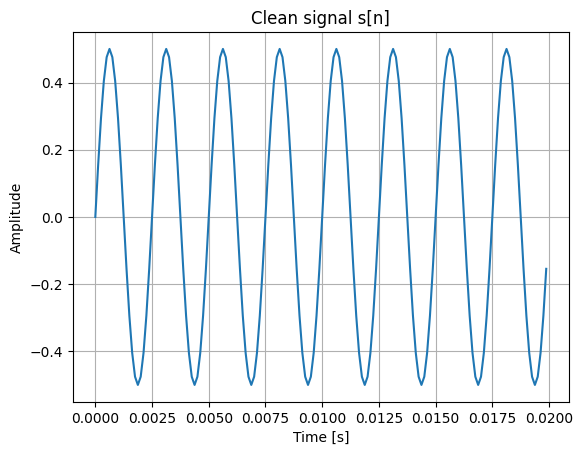

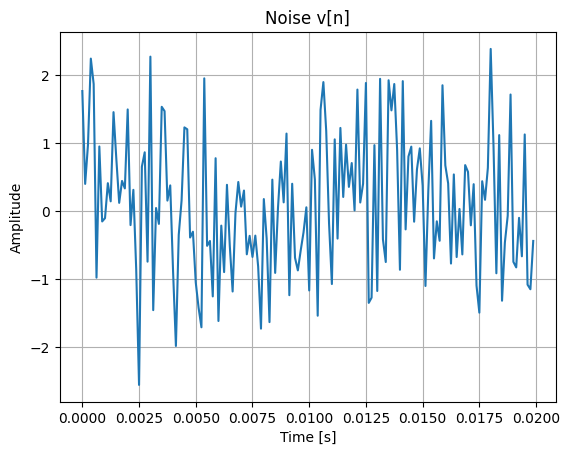

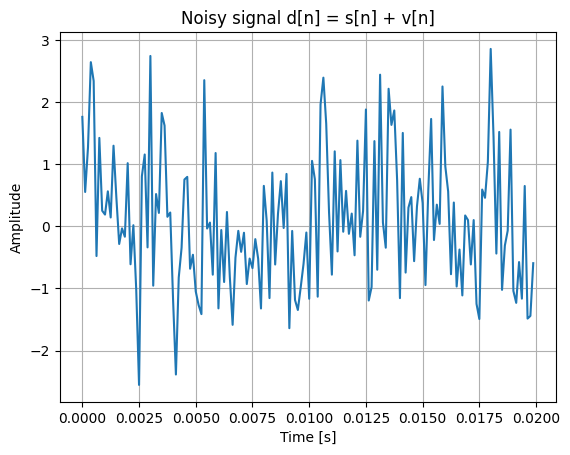

In [6]:
plot_time(s, fs, title='Clean signal s[n]', seconds=0.02)
plot_time(v, fs, title='Noise v[n]', seconds=0.02)
plot_time(d, fs, title='Noisy signal d[n] = s[n] + v[n]', seconds=0.02)

### Plot — frequency domain

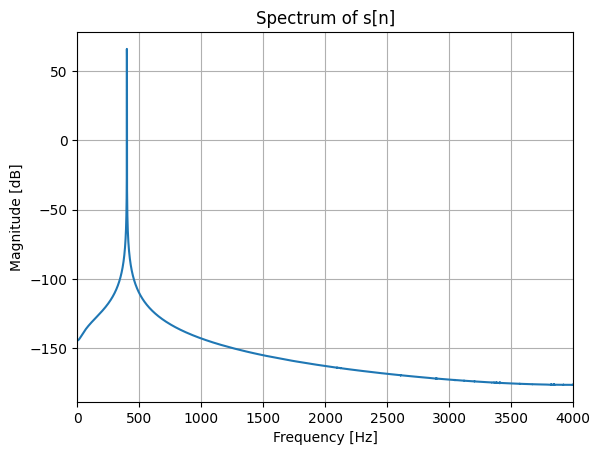

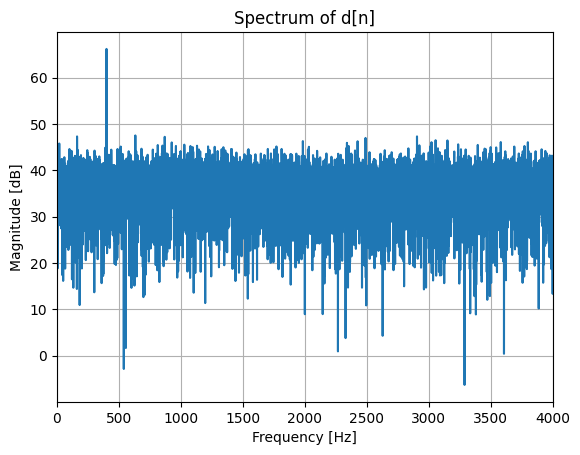

In [7]:
plot_spectrum(s, fs, title='Spectrum of s[n]')
plot_spectrum(d, fs, title='Spectrum of d[n]')

### Plot — spectrogram

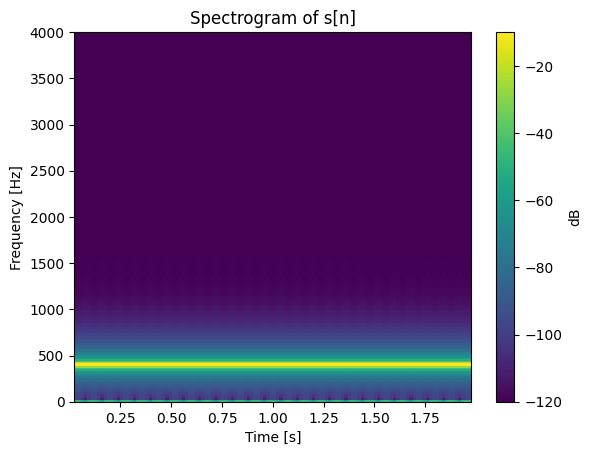

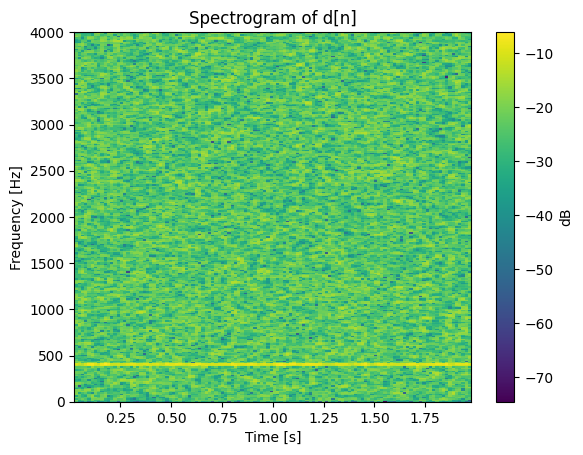

In [8]:
plot_spectrogram(s, fs, title='Spectrogram of s[n]')
plot_spectrogram(d, fs, title='Spectrogram of d[n]')

---
## 4. Design the lowpass filter `h`

Design the lowpass filter `h` with cutoff frequency 600 Hz and 128 taps.

In [9]:
numtaps = 128
cutoff_hz = 600

h = signal.firwin(numtaps, cutoff_hz, fs=fs, window='hann', pass_zero='lowpass')

print('Filter length:', len(h))
print('Cutoff frequency:', cutoff_hz, 'Hz')

Filter length: 128
Cutoff frequency: 600 Hz


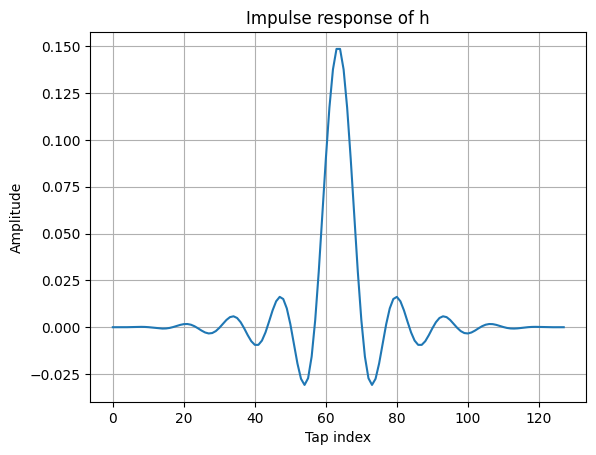

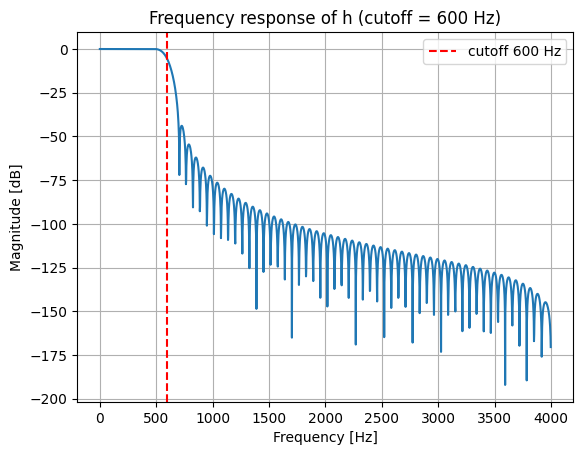

In [10]:
# Impulse response
plt.figure()
plt.plot(h)
plt.xlabel('Tap index')
plt.ylabel('Amplitude')
plt.title('Impulse response of h')
plt.grid(True)
plt.show()

# Frequency response
w_hz, H = signal.freqz(h, worN=2048, fs=fs)
plt.figure()
plt.plot(w_hz, 20*np.log10(np.abs(H)+1e-12))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Frequency response of h (cutoff = 600 Hz)')
plt.axvline(cutoff_hz, color='r', linestyle='--', label='cutoff 600 Hz')
plt.legend()
plt.grid(True)
plt.show()

---
## 5. Filter `d` using `np.convolve` → `s_hat`

Filter the noisy signal `d` using the filter `h` to obtain `s_hat`.

In [11]:
s_hat = np.convolve(d, h, mode='same')

print('s_hat length:', len(s_hat))

s_hat length: 16000


Filtered signal s_hat:


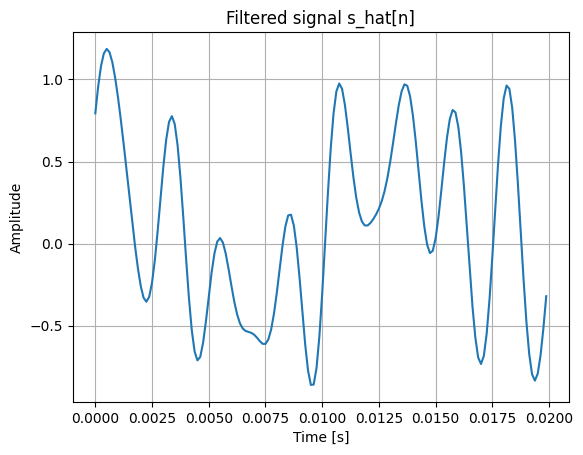

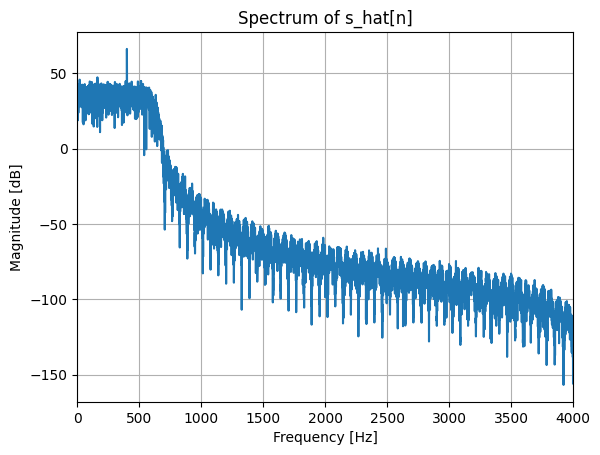

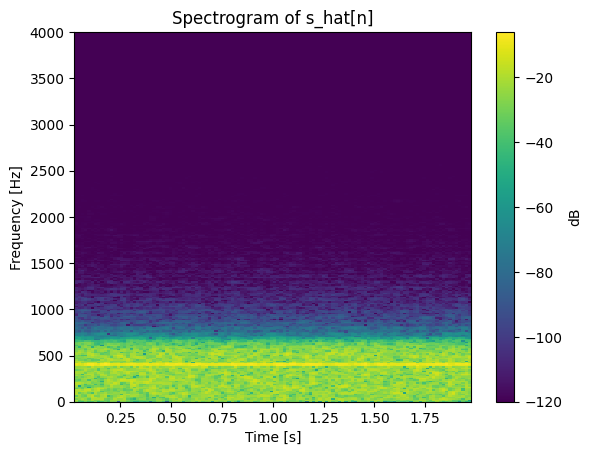

In [12]:
print('Filtered signal s_hat:')
play(s_hat, fs)

plot_time(s_hat, fs, title='Filtered signal s_hat[n]', seconds=0.02)
plot_spectrum(s_hat, fs, title='Spectrum of s_hat[n]')
plot_spectrogram(s_hat, fs, title='Spectrogram of s_hat[n]')

---
## 6. Filter `d` using overlap-and-add (convolution via DFT)

Filter `d` using the online overlap-and-add method (frame-by-frame FFT convolution).

In [13]:
def get_window(win_type, N):
    if win_type == 'rect':
        return np.ones(N)
    return signal.get_window(win_type, N, fftbins=True)

def next_pow2(n):
    return 1 << (int(n - 1).bit_length())

def ola_fft_convolve(x, h, Nw, hop, win_type='hann', nfft=None, normalize=True):
    """
    Online-ish convolution via frame-by-frame FFT and overlap-add.
    x: input signal (1D)
    h: FIR filter (1D)
    Nw: frame/window length
    hop: hop size (advance per frame)
    win_type: window type (rect, hann, hamming, blackman, ...)
    nfft: FFT size (>= Nw + len(h) - 1). If None -> next power of 2.
    normalize: if True, divide by overlap-added window power
    """
    x = np.asarray(x, dtype=float)
    h = np.asarray(h, dtype=float)
    Lh = len(h)
    if nfft is None:
        nfft = next_pow2(Nw + Lh - 1)
    w = get_window(win_type, Nw)
    y_len = len(x) + Lh - 1
    y = np.zeros(y_len)
    if normalize:
        win_acc = np.zeros(y_len)
    H = np.fft.rfft(h, nfft)
    n_frames = int(np.ceil((len(x) - 1) / hop)) + 1
    for m in range(n_frames):
        start = m * hop
        if start >= len(x):
            break
        frame = np.zeros(Nw)
        end = min(start + Nw, len(x))
        frame[:end-start] = x[start:end]
        frame_w = frame * w
        Yf = np.fft.rfft(frame_w, nfft) * H
        y_block = np.fft.irfft(Yf, nfft)
        out_start = start
        out_end = min(out_start + nfft, y_len)
        y[out_start:out_end] += y_block[:out_end - out_start]
        if normalize:
            win_end = min(start + Nw, y_len)
            win_acc[start:win_end] += (w[:win_end-start] ** 2)
    if normalize:
        nz = win_acc > 1e-12
        y[nz] /= win_acc[nz]
    return y

In [14]:
Nw  = 1024
hop = 256
nfft = next_pow2(Nw + len(h) - 1)

s_hat_ola = ola_fft_convolve(d, h, Nw=Nw, hop=hop, win_type='hann', nfft=nfft)
s_hat_ola = s_hat_ola[:N]

print('s_hat_ola length:', len(s_hat_ola))
print('nfft =', nfft)

s_hat_ola length: 16000
nfft = 2048


OLA filtered signal:


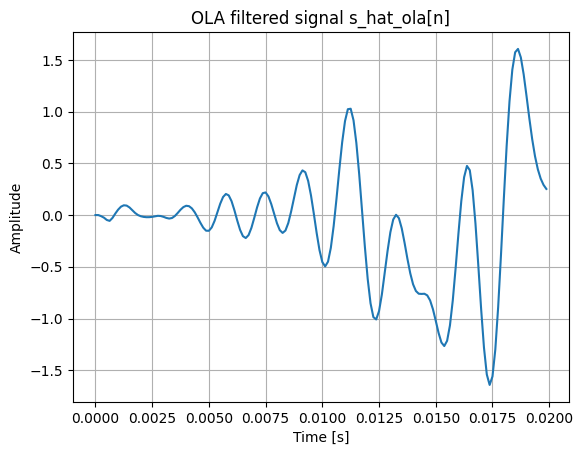

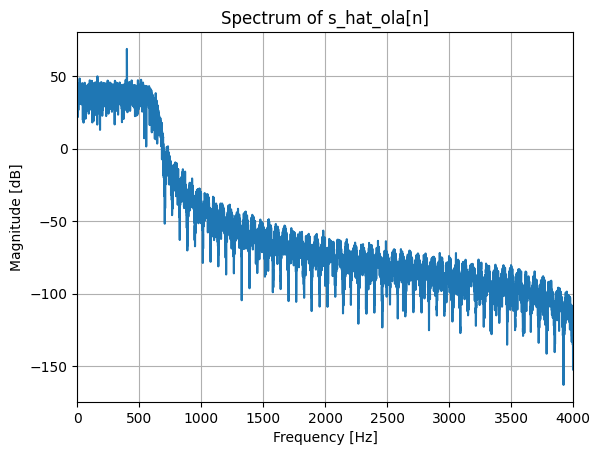

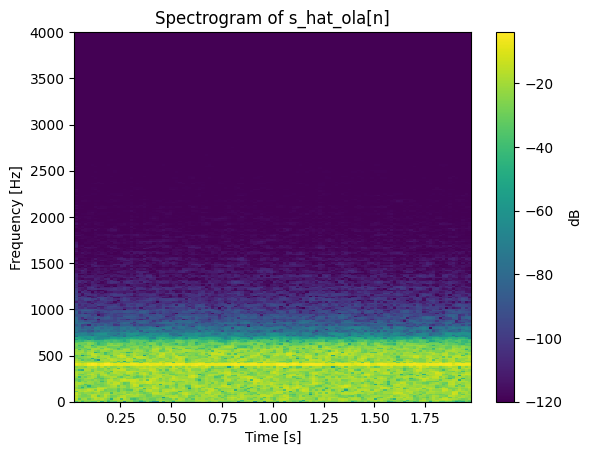

In [15]:
print('OLA filtered signal:')
play(s_hat_ola, fs)

plot_time(s_hat_ola, fs, title='OLA filtered signal s_hat_ola[n]', seconds=0.02)
plot_spectrum(s_hat_ola, fs, title='Spectrum of s_hat_ola[n]')
plot_spectrogram(s_hat_ola, fs, title='Spectrogram of s_hat_ola[n]')

---
## 7. Reference signal `g`

Obtain the signal `g` by filtering the noise `v` through the filter `b` with taps [1, 0.5, 0.3, 0.2, 0.1].

In [16]:
b = np.array([1, 0.5, 0.3, 0.2, 0.1])

g = signal.lfilter(b, [1.0], v)

print('b taps:', b)
print('g length:', len(g))

b taps: [1.  0.5 0.3 0.2 0.1]
g length: 16000


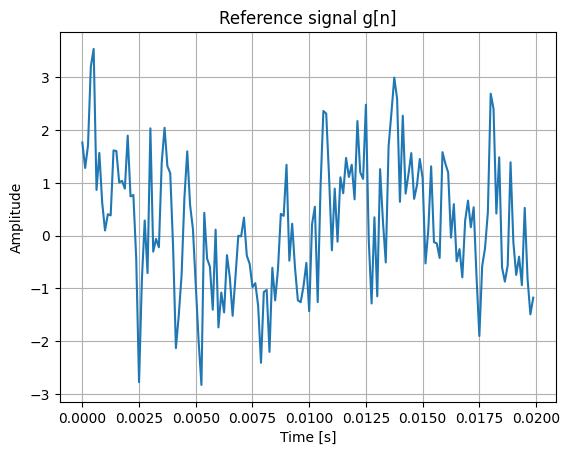

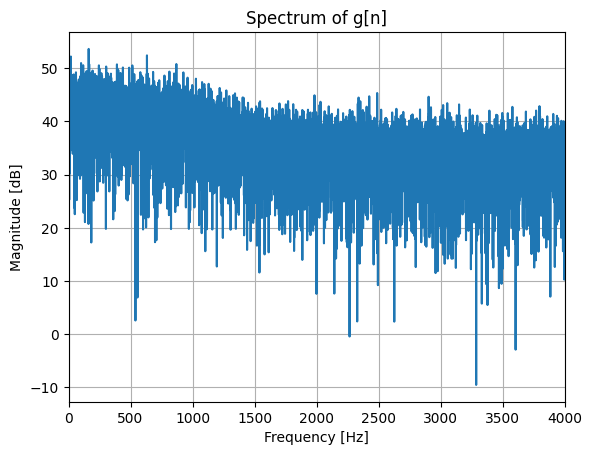

In [17]:
plot_time(g, fs, title='Reference signal g[n]', seconds=0.02)
plot_spectrum(g, fs, title='Spectrum of g[n]')

---
## 8. Adaptive filters: Wiener, Steepest Descent, LMS

Compute the Wiener filter `w`, the steepest descent filter `w_sd` and the LMS filter `w_LMS` using the signals `d` and `g`. Filter the noise through these 3 filters to obtain `s_h`, `s_sd`, `s_LMS`.

In [18]:
M = 32   # adaptive filter length

# Build data matrix from reference signal g
G = np.zeros((N, M))
for n in range(N):
    for k in range(M):
        idx = n - k
        G[n, k] = g[idx] if idx >= 0 else 0.0

print('Data matrix G shape:', G.shape)

Data matrix G shape: (16000, 32)


### Wiener filter (batch solution)

In [19]:
Rgg = (G.T @ G) / N
rgd = (G.T @ d) / N

reg = 1e-6 * np.eye(M)
w = linalg.solve(Rgg + reg, rgd)

# Filter: estimate noise from g, subtract from d
s_h = d - G @ w

print('Wiener filter (first 8 taps):', np.round(w[:8], 3))

Wiener filter (first 8 taps): [ 1.001 -0.5   -0.051 -0.026  0.026  0.052 -0.027 -0.008]


### Steepest Descent filter

In [20]:
mu_sd = 0.5 / (np.max(np.linalg.eigvals(Rgg).real) + 1e-12)
n_iters = 200
w_sd = np.zeros(M)

for k in range(n_iters):
    grad = -2*rgd + 2*(Rgg @ w_sd)
    w_sd = w_sd - mu_sd * grad

# Filter: estimate noise from g, subtract from d
s_sd = d - G @ w_sd

print('Steepest descent (first 8 taps):', np.round(w_sd[:8], 3))

Steepest descent (first 8 taps): [ 1.001 -0.5   -0.051 -0.026  0.026  0.052 -0.027 -0.008]


### LMS filter (online)

In [21]:
mu = 0.001
w_LMS = np.zeros(M)
s_LMS = np.zeros(N)

for n in range(N):
    gvec = G[n, :]
    y = w_LMS @ gvec
    e = d[n] - y
    w_LMS = w_LMS + mu * e * gvec
    s_LMS[n] = e

print('LMS final (first 8 taps):', np.round(w_LMS[:8], 3))

LMS final (first 8 taps): [ 0.995 -0.501 -0.047 -0.017  0.038  0.066 -0.012  0.006]


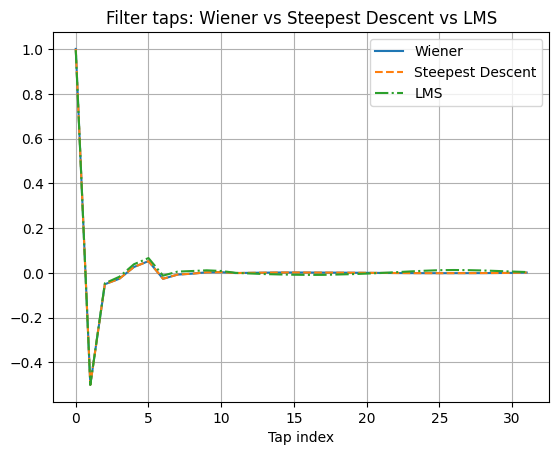

In [22]:
# Compare filter taps
plt.figure()
plt.plot(w,    label='Wiener')
plt.plot(w_sd, '--', label='Steepest Descent')
plt.plot(w_LMS,'-.', label='LMS')
plt.title('Filter taps: Wiener vs Steepest Descent vs LMS')
plt.xlabel('Tap index')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print('s_h (Wiener):')
play(s_h, fs)

print('s_sd (Steepest Descent):')
play(s_sd, fs)

print('s_LMS (LMS):')
play(s_LMS, fs)

s_h (Wiener):


s_sd (Steepest Descent):


s_LMS (LMS):


---
## 9. Spectrograms of s_hat, s_h, s_sd, s_LMS

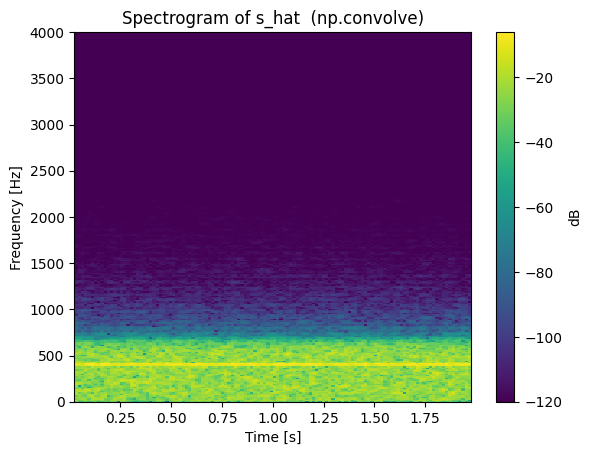

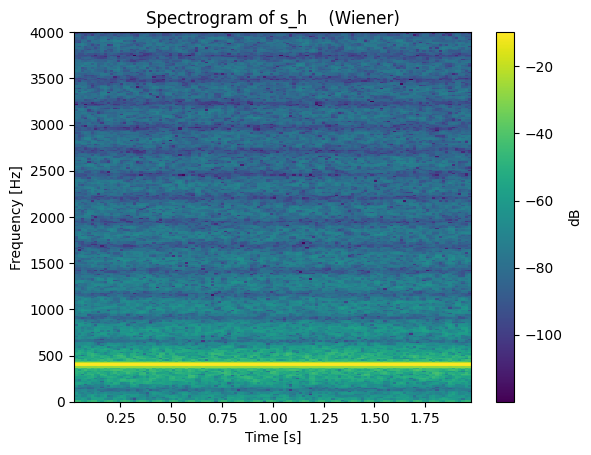

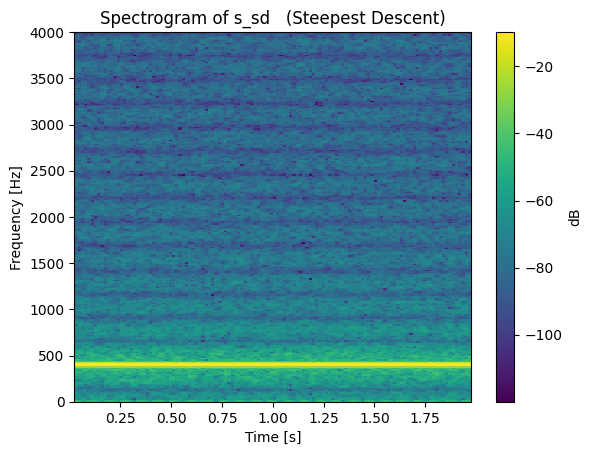

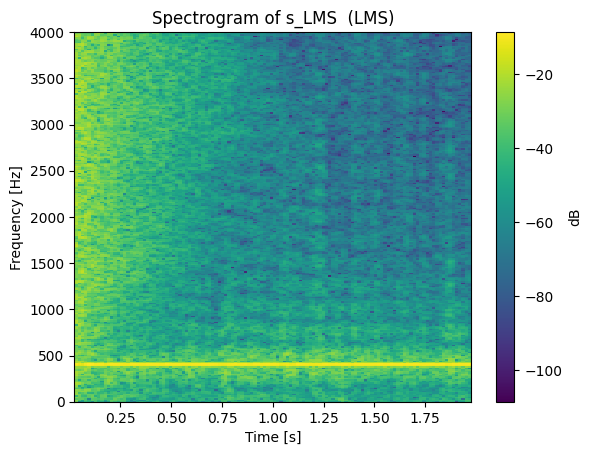

In [24]:
plot_spectrogram(s_hat,  fs, title='Spectrogram of s_hat  (np.convolve)')
plot_spectrogram(s_h,    fs, title='Spectrogram of s_h    (Wiener)')
plot_spectrogram(s_sd,   fs, title='Spectrogram of s_sd   (Steepest Descent)')
plot_spectrogram(s_LMS,  fs, title='Spectrogram of s_LMS  (LMS)')